# Creating an Arbitrary Index from Nasdaq Company Tickers

The goal of this project is to create an arbitrary stock index based on Nasdaq-listed companies whose ticker symbols follow a specific rule.

For example, the **Y Index** contains all eligible Nasdaq-listed companies whose ticker starts with the letter **Y**.

The objective is not only to create the index, but also to build a reproducible pipeline that:

1. Downloads the universe of Nasdaq-listed securities.
2. Identifies real operating companies.
3. Removes financial instruments that are not suitable for an equity index.
4. Applies eligibility rules similar to professional index providers.
5. Calculates index constituents and weights.
6. Performs exploratory data analysis (EDA) on the resulting index.

---

## 1. Data Sources

### SEC Company Tickers

The SEC provides a list of companies that file reports with the U.S. Securities and Exchange Commission.

Source:

https://www.sec.gov/files/company_tickers.json

This dataset contains:

- Company name
- Ticker symbol
- SEC CIK identifier

Example:

```json
{
"ticker": "AAPL",
"title": "Apple Inc.",
"cik_str": 320193
}
```

The SEC dataset is useful because it represents **actual reporting companies**, unlike exchange symbol lists that may contain many financial products.

---

### Nasdaq Listed Securities

Source:

https://ftp.nasdaqtrader.com/SymbolDirectory/nasdaqlisted.txt

This file contains all securities listed on Nasdaq.

It includes:

- Common stocks
- ADRs
- ETFs
- Warrants
- Rights
- Units
- Preferred shares
- Other financial instruments

The Nasdaq dataset is required because it provides the official universe of securities traded on Nasdaq.

### Data location

Both files are in the `/data` directory.

---

## 2. Building the Company Universe

We combine the SEC and Nasdaq datasets to create a clean universe of companies.

The process is:


Nasdaq Listed Securities --> Remove ETFs and test securities --> Join with SEC reporting companies -- >
Remove non-equity securities --> Remove SPACs --> Apply company age filters (remove less than 1 year)

This gives us the universe where we can select our companies for the index.

---

## 3. Security Filtering Rules

We exclude the following securities because they do not represent ordinary company ownership.

- ETFs
- Test issues
- NextShares
- Warrants
- Rights
- Units
- Preferred shares
- Bonds and notes
- Other derivative instruments

Examples:

| Symbol | Type | Action |
|---|---|---|
| AAPL | Common stock | Keep |
| YICC | Common stock | Keep |
| YICCU | Unit | Remove |
| YICCW | Warrant | Remove |

---

## 4. Company Eligibility Rules

We apply other filters to create a more realistic index universe:

### Remove SPACs

We remove Special Purpose Acquisition Companies.

Examples of excluded names:

- Acquisition Corp
- Acquisition Holdings
- Blank Check Company

The reason is that these entities do not represent mature operating businesses.

---

### Minimum Company Age

We exclude companies younger than one year.

This avoids including:

- Recently created SPACs
- Very recent IPOs
- **Companies without sufficient trading history**

---

## 5. Creating the Letter-Based Index Universe

After cleaning the Nasdaq company universe, we group companies by ticker letter.

- A Index
- J Index
- Y Index
- Any other ticker-based universe

## GOAL: Find the Most Underrepresented Letter in the tickers, and Create an Index Based on it

In [ ]:
from src.universe import build_company_universe
from src.index import (
    companies_with_letter,
    ticker_letter_counts,
    least_common_letters,
    build_j_index_constituents,
    calculate_j_index,
    download_index_prices,
)
from src.utils import save_parquet_cache
from openbb import obb

obb.user.preferences.output_type = "dataframe"

In [2]:
universe = build_company_universe(
    "data/sec.json",
    "data/nasdaqlisted.txt",
)

In [3]:
counts = ticker_letter_counts(universe)

print(counts)

least_common_letters(universe)

   letter  companies
0       J         40
1       Q         52
2       Z         91
3       U        177
4       W        178
5       Y        192
6       K        229
7       V        238
8       H        247
9       F        281
10      X        301
11      G        339
12      D        365
13      P        392
14      O        430
15      B        438
16      E        446
17      M        458
18      I        525
19      L        538
20      N        602
21      S        657
22      R        658
23      C        660
24      A        661
25      T        666


,letter,companies
0,J,40
1,Q,52
2,Z,91
3,U,177
4,W,178
5,Y,192
6,K,229
7,V,238
8,H,247
9,F,281


In [4]:
j_index = companies_with_letter(universe, "J")

j_index

,Symbol,Security Name,Market Category,Test Issue,Financial Status,Round Lot Size,ETF,NextShares,CIK,Company
0,AIRJ,AirJoule Technologies Corporation - Class A Co...,S,N,N,100.0,N,N,1855474,AirJoule Technologies Corp.
1,BJDX,"Bluejay Diagnostics, Inc. - Common Stock",S,N,N,100.0,N,N,1704287,"Bluejay Diagnostics, Inc."
2,BJRI,"BJ's Restaurants, Inc. - Common Stock",Q,N,N,100.0,N,N,1013488,BJs RESTAURANTS INC
3,BOTJ,"Bank of the James Financial Group, Inc. - Comm...",S,N,N,100.0,N,N,1275101,BANK OF THE JAMES FINANCIAL GROUP INC
4,CJMB,Callan JMB Inc. - Common Stock,S,N,D,100.0,N,N,2032545,CALLAN JMB INC.
5,DJCO,Daily Journal Corp. (S.C.) - Common Stock,S,N,N,40.0,N,N,783412,DAILY JOURNAL CORP
6,DJT,Trump Media & Technology Group Corp. - Common ...,G,N,N,100.0,N,N,1849635,Trump Media & Technology Group Corp.
7,EJH,E-Home Household Service Holdings Limited - Or...,S,N,D,100.0,N,N,1769768,E-Home Household Service Holdings Ltd
8,INTJ,Intelligent Group Limited - Class A Ordinary S...,S,N,N,100.0,N,N,1916416,Intelligent Group Ltd
9,JACK,Jack In The Box Inc. - Common Stock,Q,N,N,100.0,N,N,807882,JACK IN THE BOX INC


In [ ]:
save_parquet_cache(j_index, "data/j_index.parquet")

## Retrieving more data for the J Index

The letter that's more under-represented in the index is the letter J. This allows us to create the J Index, which has 40 companies in it.

Next, we will create a dataframe with some extra information about these companies (market capitalization and size, and sector). With this extra data, we'll be able to do some initial EDA explorations.

In [6]:
j_index_constituents = build_j_index_constituents(j_index)

j_index_constituents

,Symbol,Company,Sector,MarketCap,Weight,Size,Currency,Country,SIC,SIC_Description
0,JKHY,JACK HENRY & ASSOCIATES INC,Technology,10698826752,0.525998,Large Cap,USD,United States,7373,Services-Computer Integrated Systems Design
1,DJT,Trump Media & Technology Group Corp.,Communication Services,2370724864,0.116554,Mid Cap,USD,United States,7370,"Services-Computer Programming, Data Processing..."
2,JJSF,J&J SNACK FOODS CORP,Consumer Defensive,1433511168,0.070477,Small Cap,USD,United States,2052,Cookies & Crackers
3,BJRI,BJs RESTAURANTS INC,Consumer Cyclical,1405191552,0.069085,Small Cap,USD,United States,5812,Retail-Eating Places
4,RJET,REPUBLIC AIRWAYS HOLDINGS INC.,Industrials,809681664,0.039807,Small Cap,USD,United States,4512,"Air Transportation, Scheduled"
5,DJCO,DAILY JOURNAL CORP,Technology,792327872,0.038954,Small Cap,USD,United States,2711,Newspapers: Publishing or Publishing & Printing
6,JOUT,JOHNSON OUTDOORS INC,Consumer Cyclical,481731104,0.023684,Small Cap,USD,United States,3949,"Sporting & Athletic Goods, NEC"
7,JMSB,"John Marshall Bancorp, Inc.",Financial Services,315267072,0.015500,Small Cap,USD,United States,6022,State Commercial Banks
8,AIRJ,AirJoule Technologies Corp.,Industrials,301910464,0.014843,Small Cap,USD,United States,3585,Air-Cond & Warm Air Heatg Equip & Comm & Indl ...
9,JACK,JACK IN THE BOX INC,Consumer Cyclical,277521120,0.013644,Micro Cap,USD,United States,5812,Retail-Eating Places


## EDA: J Index Constituents

With the 40 companies enriched with market data, we can now explore the composition of the index.

In [7]:
j_index_constituents[
    ["Symbol", "Company", "Sector", "MarketCap", "Weight", "Size", "Country"]
]

,Symbol,Company,Sector,MarketCap,Weight,Size,Country
0,JKHY,JACK HENRY & ASSOCIATES INC,Technology,10698826752,0.525998,Large Cap,United States
1,DJT,Trump Media & Technology Group Corp.,Communication Services,2370724864,0.116554,Mid Cap,United States
2,JJSF,J&J SNACK FOODS CORP,Consumer Defensive,1433511168,0.070477,Small Cap,United States
3,BJRI,BJs RESTAURANTS INC,Consumer Cyclical,1405191552,0.069085,Small Cap,United States
4,RJET,REPUBLIC AIRWAYS HOLDINGS INC.,Industrials,809681664,0.039807,Small Cap,United States
5,DJCO,DAILY JOURNAL CORP,Technology,792327872,0.038954,Small Cap,United States
6,JOUT,JOHNSON OUTDOORS INC,Consumer Cyclical,481731104,0.023684,Small Cap,United States
7,JMSB,"John Marshall Bancorp, Inc.",Financial Services,315267072,0.015500,Small Cap,United States
8,AIRJ,AirJoule Technologies Corp.,Industrials,301910464,0.014843,Small Cap,United States
9,JACK,JACK IN THE BOX INC,Consumer Cyclical,277521120,0.013644,Micro Cap,United States


### Size Distribution

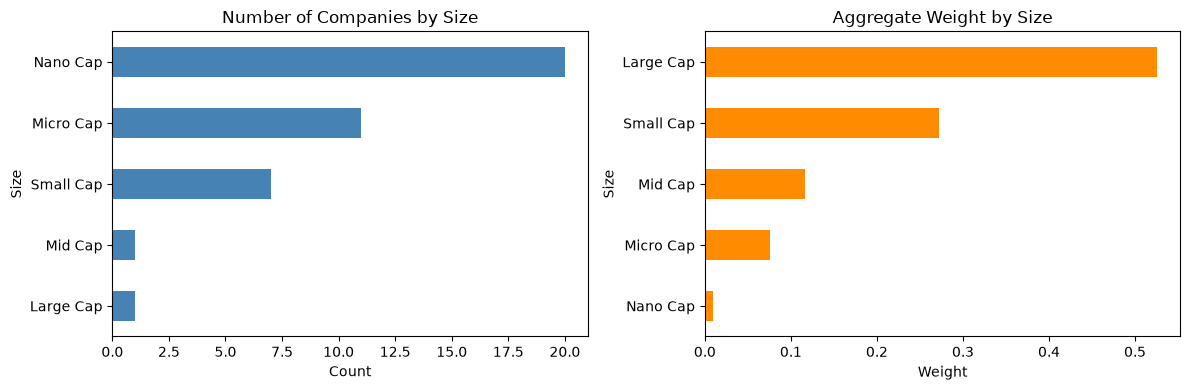

Size
Large Cap     1
Mid Cap       1
Small Cap     7
Micro Cap    11
Nano Cap     20
Name: count, dtype: int64

Weight by size:
Size
Large Cap    52.60%
Small Cap    27.24%
Mid Cap      11.66%
Micro Cap     7.53%
Nano Cap      0.98%
Name: Weight, dtype: str


In [8]:
import matplotlib.pyplot as plt

size_order = ["Mega Cap", "Large Cap", "Mid Cap", "Small Cap", "Micro Cap", "Nano Cap"]
size_counts = (
    j_index_constituents["Size"].value_counts().reindex(size_order).dropna().astype(int)
)
size_weights = (
    j_index_constituents.groupby("Size")["Weight"].sum().reindex(size_order).dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

size_counts.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Number of Companies by Size")
axes[0].set_xlabel("Count")

size_weights.sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Aggregate Weight by Size")
axes[1].set_xlabel("Weight")

plt.tight_layout()
plt.show()

print(size_counts)
print("\nWeight by size:")
print(size_weights.sort_values(ascending=False).map("{:.2%}".format))

### Country Exposure

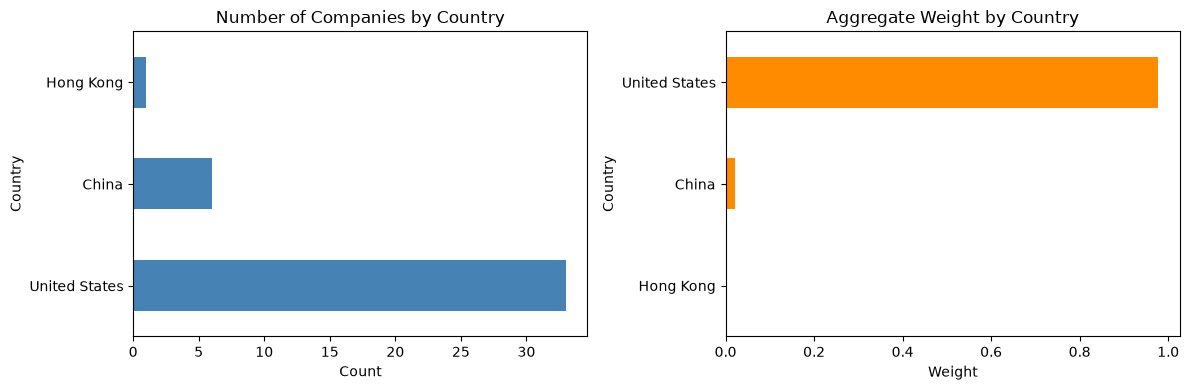

Country
United States    33
China             6
Hong Kong         1
Name: count, dtype: int64

Weight by country:
Country
United States    97.73%
China             2.24%
Hong Kong         0.03%
Name: Weight, dtype: str


In [9]:
country_counts = j_index_constituents["Country"].value_counts()
country_weights = j_index_constituents.groupby("Country")["Weight"].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

country_counts.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Number of Companies by Country")
axes[0].set_xlabel("Count")

country_weights.sort_values().plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Aggregate Weight by Country")
axes[1].set_xlabel("Weight")

plt.tight_layout()
plt.show()

print(country_counts)
print("\nWeight by country:")
print(country_weights.sort_values(ascending=False).map("{:.2%}".format))

### Total Market Cap

In [10]:
total_market_cap = j_index_constituents["MarketCap"].sum()

print(f"Total market cap: ${total_market_cap:,.0f}")
print(f"Number of constituents: {len(j_index_constituents)}")
print(f"Average market cap: ${total_market_cap / len(j_index_constituents):,.0f}")
print(
    f"Largest holding: {j_index_constituents.iloc[0]['Symbol']} ({j_index_constituents.iloc[0]['Weight']:.1%})"
)
print(
    f"Smallest holding: {j_index_constituents.iloc[-1]['Symbol']} ({j_index_constituents.iloc[-1]['Weight']:.4%})"
)

Total market cap: $20,340,065,819
Number of constituents: 40
Average market cap: $508,501,645
Largest holding: JKHY (52.6%)
Smallest holding: LBGJ (0.0005%)


### Fundamental Metrics

In [ ]:
fundamentals_T = j_index_fundamentals.T.reset_index().rename(columns={"index": "Symbol"})
fundamentals_T = fundamentals_T[["Symbol", "market_cap", "pe_ratio", "forward_pe", "price_to_book",
                                  "enterprise_to_ebitda", "gross_margin", "profit_margin",
                                  "return_on_equity", "debt_to_equity", "beta", "price_return_1y"]]

j_index_full = j_index_constituents.merge(fundamentals_T, on="Symbol", how="left", suffixes=("", "_fund"))

j_index_full.head(10)

### Valuation Profile

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

j_index_full["pe_ratio"].dropna().hist(bins=20, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("P/E Ratio Distribution")
axes[0].set_xlabel("P/E")

j_index_full["price_to_book"].dropna().hist(bins=20, ax=axes[1], color="darkorange", edgecolor="white")
axes[1].set_title("Price/Book Distribution")
axes[1].set_xlabel("P/B")

j_index_full["enterprise_to_ebitda"].dropna().clip(-20, 50).hist(bins=20, ax=axes[2], color="seagreen", edgecolor="white")
axes[2].set_title("EV/EBITDA Distribution")
axes[2].set_xlabel("EV/EBITDA")

plt.tight_layout()
plt.show()

print("Median P/E:", j_index_full["pe_ratio"].median())
print("Median P/B:", j_index_full["price_to_book"].median())
print("Median EV/EBITDA:", j_index_full["enterprise_to_ebitda"].median())

### Profitability

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

valid = j_index_full.dropna(subset=["gross_margin", "profit_margin", "MarketCap"])
sizes = valid["MarketCap"] / valid["MarketCap"].max() * 500

scatter = ax.scatter(valid["gross_margin"], valid["profit_margin"],
                     s=sizes, alpha=0.6, c=valid.index, cmap="viridis", edgecolors="white")

for _, row in valid.iterrows():
    ax.annotate(row["Symbol"], (row["gross_margin"], row["profit_margin"]),
                fontsize=6, alpha=0.7, ha="center", va="bottom")

ax.set_title("Gross Margin vs Profit Margin (bubble = market cap)")
ax.set_xlabel("Gross Margin")
ax.set_ylabel("Profit Margin")
ax.axhline(0, color="red", linewidth=0.5, linestyle="--")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Risk Profile

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

j_index_full["beta"].dropna().hist(bins=15, ax=axes[0], color="crimson", edgecolor="white")
axes[0].set_title("Beta Distribution")
axes[0].set_xlabel("Beta")
axes[0].axvline(1.0, color="black", linewidth=1, linestyle="--", label="Market = 1.0")
axes[0].legend()

risk_cols = ["overall_risk", "audit_risk", "board_risk", "compensation_risk", "shareholder_rights_risk"]
available_risk = [c for c in risk_cols if c in j_index_full.columns]
risk_means = j_index_full[available_risk].mean().sort_values()
risk_means.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Average Risk Scores (lower = safer)")
axes[1].set_xlabel("Score")

plt.tight_layout()
plt.show()

print("Median Beta:", j_index_full["beta"].median())

In [11]:
j_index_list = j_index_constituents.Symbol.to_list()
comma_separated_j_index = ",".join(j_index_list)

In [12]:
j_index_fundamentals = obb.equity.fundamental.metrics(
    comma_separated_j_index, provider="yfinance"
)

display(j_index_fundamentals.T)

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
symbol,JKHY,JJSF,JMSB,DJCO,RJET,DJT,BJRI,JOUT,AIRJ,JDZG,...,JCSE,INTJ,EJH,JWEL,JUNS,JTAI,JEM,JZXN,LBGJ,BJDX
currency,USD,USD,USD,USD,USD,USD,USD,USD,USD,CNY,...,SGD,HKD,USD,USD,USD,USD,HKD,USD,USD,USD
market_cap,10929386496,1457328000,327897504,793843456,838715904,2668173056,1445544064,494929184,312770560,274000000,...,7719880,5500867,4447894,4277035,5357699,2765247,3963093,1833800,91012,1108593
pe_ratio,21.513985,26.07718,13.430636,56.824455,10.118644,NaN,34.562813,NaN,NaN,NaN,...,3.0625,NaN,0.00207,NaN,NaN,0.004526,NaN,NaN,NaN,NaN
forward_pe,21.662106,18.199062,10.934118,NaN,NaN,NaN,25.82811,20.106384,-14.561635,NaN,...,NaN,NaN,NaN,NaN,1.851667,-0.9725,NaN,NaN,NaN,-3.348125
peg_ratio,2.04,5.12,NaN,4.32,NaN,NaN,2.27,1.4,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
peg_ratio_ttm,2.0353,NaN,NaN,NaN,NaN,NaN,2.2728,1.3979,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enterprise_to_ebitda,15.117,9.155,NaN,25.981,4.961,-5.578,14.349,15.119,-18.194,-1.558,...,1.256,2.986,95.63,-0.624,NaN,1.049,0.918,-0.044,-7.542,0.367
earnings_growth,0.125,-0.642,0.398,NaN,-0.147,NaN,-0.293,3.045,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.117,NaN
earnings_growth_quarterly,0.106,-0.652,0.375,NaN,-0.007,NaN,-0.33,3.084,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.231,NaN


## J Index Calculation

Now that we have the 40 constituents with their market-cap weights, we can calculate the actual J Index time series.

### Methodology

1. **Download adjusted close prices** for all 40 tickers over the last year
2. **Calculate daily simple returns** for each ticker
3. **Apply fixed weights** — multiply each ticker's return by its market-cap weight
4. **Renormalize daily** — if a ticker has no data on a given day, redistribute its weight to available tickers
5. **Chain into an index** — start at 1000 and compound the weighted portfolio returns

This is a **price return index** (dividends not reinvested) with **fixed weights** (no rebalancing).

In [13]:
j_index_timeseries = calculate_j_index(j_index_constituents, lookback_days=365)

j_index_timeseries

,Date,Index,Daily_Return
0,0,1000.000000,0.000000
1,1,987.678895,-0.012321
2,2,978.007870,-0.009792
3,3,961.180327,-0.017206
4,4,944.938444,-0.016898
...,...,...,...
245,245,979.567057,0.007079
246,246,963.622383,-0.016277
247,247,947.162664,-0.017081
248,248,944.548451,-0.002760


## J Index Performance

The J Index starts at 1000 and compounds daily weighted returns across all 40 constituents. Weights are based on market capitalization and are renormalized daily for available tickers.

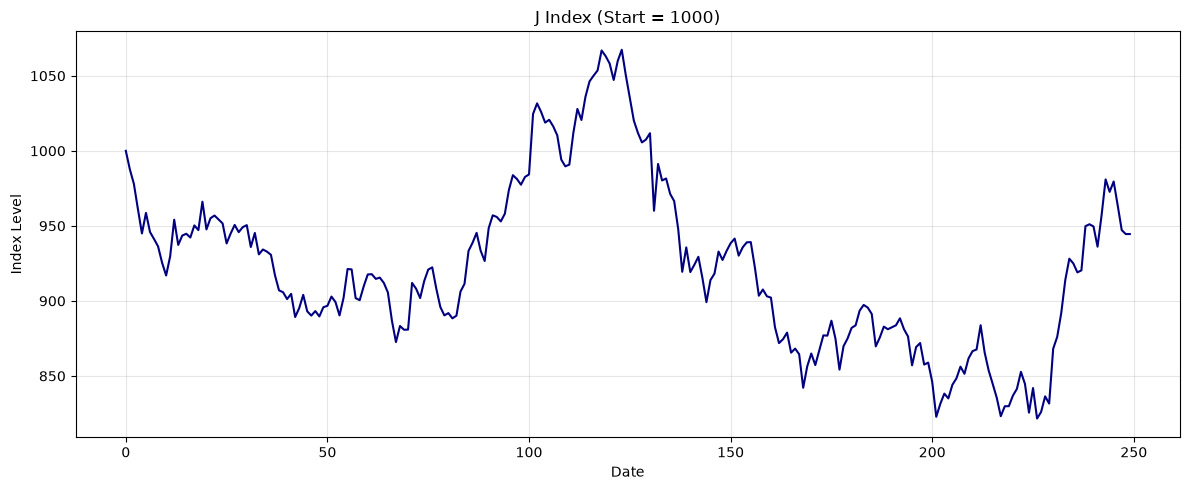

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    j_index_timeseries["Date"], j_index_timeseries["Index"], linewidth=1.5, color="navy"
)
ax.set_title("J Index (Start = 1000)")
ax.set_xlabel("Date")
ax.set_ylabel("Index Level")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Individual Company Performance

Normalized price returns for each constituent (all starting at 1.0), showing relative performance over the period.

In [ ]:
import plotly.graph_objects as go

prices = download_index_prices(j_index_constituents, lookback_days=365)
normalized = prices / prices.iloc[0]

fig = go.Figure()

for ticker in normalized.columns:
    fig.add_trace(go.Scatter(
        x=normalized.index,
        y=normalized[ticker],
        name=ticker,
        mode="lines",
        line=dict(width=0.7, color=None),
        opacity=0.6,
        hovertemplate=f"{ticker}: %{{y:.2f}}<extra></extra>",
    ))

# Overlay J Index (renormalized)
index_normalized = j_index_timeseries.set_index("Date")["Index"]
index_normalized = index_normalized / index_normalized.iloc[0]
fig.add_trace(go.Scatter(
    x=index_normalized.index,
    y=index_normalized.values,
    name="J Index",
    mode="lines",
    line=dict(width=3, color="black"),
    hovertemplate="J Index: %{y:.2f}<extra></extra>",
))

fig.update_layout(
    title="J Index Constituents \u2014 Normalized Price Returns",
    xaxis_title="Date",
    yaxis_title="Normalized Price (Start = 1.0)",
    hovermode="x unified",
    height=600,
    legend=dict(font=dict(size=9)),
)

fig.show()